In [11]:
# %%
"""
# Multi-Class Intent Classifier for AI Assistant
Author: Rhishi Kumar Ayyappan

This notebook builds a complete multi-class text classifier, a core
component for any modern AI assistant or chatbot. The goal is to
build a "router" that can understand a user's query and classify it
into one of 77 pre-defined intents (e.g., `check_balance`, `report_fraud`).

## Project Stack:
- **Model:** `distilbert-base-uncased` (Lightweight, fast, and high-performing)
- **Dataset:** `banking77` (A real-world dataset of 77 banking intents)
- **Frameworks:** Hugging Face `transformers`, `datasets`, and `scikit-learn`

## Key Features & Metrics Demonstrated:
- **Full Training Lifecycle:** Demonstrates data loading, preprocessing,
  model fine-tuning, and evaluation.
- **High Performance:** Runs in ~10-15 minutes on a free Colab T4 GPU.
- **Robust Metrics:** Generates a full `classification_report` with
  Precision, Recall, and F1-score for all 77 intents.
- **Inference Pipeline:** Shows the final, trained model classifying
  new, unseen user queries in real-time.
"""

# %%
"""
### Cell 1: Install Dependencies
Install all necessary libraries from Hugging Face and scikit-learn.
"""
print("--- Cell 1: Installing Dependencies ---")
!pip install transformers datasets scikit-learn torch
print("--- Dependencies installed ---")


# %%
"""
### Cell 2: Import Key Libraries
Load all modules for data processing, modeling, and evaluation.
"""
print("--- Cell 2: Importing Libraries ---")
import torch
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
# We use scikit-learn for robust, standard metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report
print("--- Libraries imported ---")


# %%
"""
### Cell 3: Load Dataset & Create Label Mappings
[FIX 1] Load the Banking77 dataset. We programmatically extract the label
names into a new variable `label_names` to avoid name collisions.
"""
print("--- Cell 3: Loading Banking77 Dataset ---")
dataset = load_dataset("banking77")

# [FIX 1] Get the list of intent names into `label_names`
label_names = dataset['train'].features['label'].names
num_labels = len(label_names)

# Create the critical label-to-ID mappings
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

print(f"Dataset loaded. Number of intents (classes): {num_labels}")
print(f"Example intent [ID 0]: {id2label[0]}")
print(f"Example intent [ID 10]: {id2label[10]}")
print("\nDataset structure:")
print(dataset)


# %%
"""
### Cell 4: Load Tokenizer
Load the tokenizer for our chosen model, DistilBERT. This will
convert raw text into token IDs the model can understand.
"""
print("--- Cell 4: Loading Tokenizer ---")
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
print(f"Tokenizer for '{model_name}' loaded.")


# %%
"""
### Cell 5: Preprocessing Function
Create a function to tokenize the text and apply it to the
entire dataset using the high-speed `.map()` method.
"""
print("--- Cell 5: Preprocessing Dataset ---")

def preprocess_function(examples):
    # Tokenize the text. We truncate to 128 tokens, which is
    # more than enough for these short queries.
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# Apply the function to all splits of the dataset
tokenized_dataset = dataset.map(preprocess_function, batched=True)

# Clean up the dataset for the Trainer
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset.set_format("torch")

print("Tokenization complete.")
print("\nExample of a tokenized sample:")
print(tokenized_dataset['train'][0])


# %%
"""
### Cell 6: Load Pre-trained Model
Load the DistilBERT model. We pass our `num_labels`, `id2label`,
and `label2id` maps directly to the model config. This is the
key to ensuring the model's output layer matches our dataset perfectly.
"""
print("--- Cell 6: Loading Model ---")
# This warning is expected: we are intentionally initializing a new
# classification head for our specific 77-label task.
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# Send model to the GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Model '{model_name}' loaded on {device}.")
print(f"Model configured for {model.config.num_labels} labels.")


# %%
"""
### Cell 7: Setup Trainer & Evaluation Metrics
[FIX 2] Define the `TrainingArguments`. This version uses
the updated `eval_strategy` and `save_strategy` argument names.
[FIX 3] Adds `report_to="none"` to disable wandb logging.
"""
print("--- Cell 7: Configuring Trainer ---")

# 1. Define the metrics computation function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Calculate metrics
    acc = accuracy_score(labels, predictions)
    # Use "weighted" F1 for multi-class classification
    f1 = f1_score(labels, predictions, average="weighted")

    return {"accuracy": acc, "f1": f1}

# 2. Define Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,

    # [FIX 2] Renamed from 'evaluation_strategy'
    eval_strategy="epoch",
    # [FIX 2] Renamed from 'save_strategy'
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    push_to_hub=False,

    # [FIX 3] Disable all external logging (like wandb)
    report_to="none",
)

# 3. Instantiate the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)
print("Trainer configured successfully.")


# %%
"""
### Cell 8: Fine-Tune the Model
Run the training! This will take ~10-15 minutes on a
Colab T4 GPU. The `trainer` will automatically handle the
training loop, evaluation, and saving the best model.
"""
print("--- Cell 8: Starting Model Fine-Tuning ---")
print("This will take ~10-15 minutes...")
trainer.train()
print("--- Training Complete ---")

# Evaluate the final best model on the test set
print("--- Evaluating Final Model on Test Set ---")
eval_results = trainer.evaluate()

print("\n--- Final Model Metrics (Test Set) ---")
print(f"  Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"  F1-Score (Weighted): {eval_results['eval_f1']:.4f}")
print("--------------------------------------")


# %%
"""
### Cell 9: Final Evaluation & Robust Inference Pipeline
[FIX 1] This cell has been corrected to fix the variable name collision.
It now correctly generates the report and implements a confidence
threshold for robust, real-world inference.
"""
print("--- Cell 9: Final Evaluation & Robust Inference ---")

# 1. Get full predictions for the test set
print("Generating full classification report...")
# [FIX 1] Use `true_labels` to store the prediction output,
# preserving our `label_names` list from Cell 3.
predictions, true_labels, _ = trainer.predict(tokenized_dataset["test"])
y_pred = np.argmax(predictions, axis=1)
y_true = true_labels

# 2. Print the Classification Report
# [FIX 1] Pass the correct `label_names` variable (from Cell 3)
# to `target_names`.
print("\n--- Full Classification Report (Test Set) ---")
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

# 3. Create a clean pipeline for new queries
print("\n--- Building Inference Pipeline for New Queries ---")
classifier = pipeline(
    "text-classification",
    model=trainer.model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

def classify_intent(text, confidence_threshold=0.50):
    """
    Helper function to classify text and print a clean output.
    Includes a confidence threshold to filter OOD queries.
    """
    result = classifier(text)
    score = result[0]['score']
    label = result[0]['label']

    print(f"Query: '{text}'")

    if score < confidence_threshold:
        print(f"--> Intent: UNKNOWN (Out-of-Distribution)")
        print(f"    (Confidence: {score:.4f} for '{label}' was below threshold of {confidence_threshold})\n")
    else:
        print(f"--> Intent: {label} (Confidence: {score:.4f})\n")

# 4. Test the pipeline
print("\n--- Testing Pipeline with Unseen Queries ---")
classify_intent("How much money is in my checking account?") # Will likely fail (OOD)
classify_intent("Can I transfer $500 to my friend?") # Might pass
classify_intent("I think my card was stolen, please help!") # Will pass
# Test the out-of-domain query again
classify_intent("What's the weather like today in London?") # Will fail (OOD)
# Add a query that *is* in the training data
classify_intent("I need to check my balance.")

print("--- Inference Test Complete ---")

--- Cell 1: Installing Dependencies ---
--- Dependencies installed ---
--- Cell 2: Importing Libraries ---
--- Libraries imported ---
--- Cell 3: Loading Banking77 Dataset ---
Dataset loaded. Number of intents (classes): 77
Example intent [ID 0]: activate_my_card
Example intent [ID 10]: card_acceptance

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})
--- Cell 4: Loading Tokenizer ---
Tokenizer for 'distilbert-base-uncased' loaded.
--- Cell 5: Preprocessing Dataset ---


Map:   0%|          | 0/10003 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Tokenization complete.

Example of a tokenized sample:
{'label': tensor(11), 'input_ids': tensor([ 101, 1045, 2572, 2145, 3403, 2006, 2026, 4003, 1029,  102,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1,

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-729755698.py:187: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,3.299700,2.655798,0.559740,0.497487
2,0.910100,0.660616,0.874675,0.870038
3,0.379100,0.406305,0.905844,0.904976


--- Training Complete ---
--- Evaluating Final Model on Test Set ---



--- Final Model Metrics (Test Set) ---
  Accuracy: 0.9058
  F1-Score (Weighted): 0.9050
--------------------------------------
--- Cell 9: Final Evaluation & Robust Inference ---
Generating full classification report...


Device set to use cuda:0



--- Full Classification Report (Test Set) ---
                                                  precision    recall  f1-score   support

                                activate_my_card     1.0000    0.9750    0.9873        40
                                       age_limit     0.9756    1.0000    0.9877        40
                         apple_pay_or_google_pay     1.0000    1.0000    1.0000        40
                                     atm_support     1.0000    0.9750    0.9873        40
                                automatic_top_up     1.0000    0.9000    0.9474        40
         balance_not_updated_after_bank_transfer     0.7838    0.7250    0.7532        40
balance_not_updated_after_cheque_or_cash_deposit     0.9487    0.9250    0.9367        40
                         beneficiary_not_allowed     0.9459    0.8750    0.9091        40
                                 cancel_transfer     0.9750    0.9750    0.9750        40
                            card_about_to_expire    



--- Cell 10: Visualizing Model Confusion (Error Heatmap) ---
Plotting heatmap for the Top 15 most confused intents...


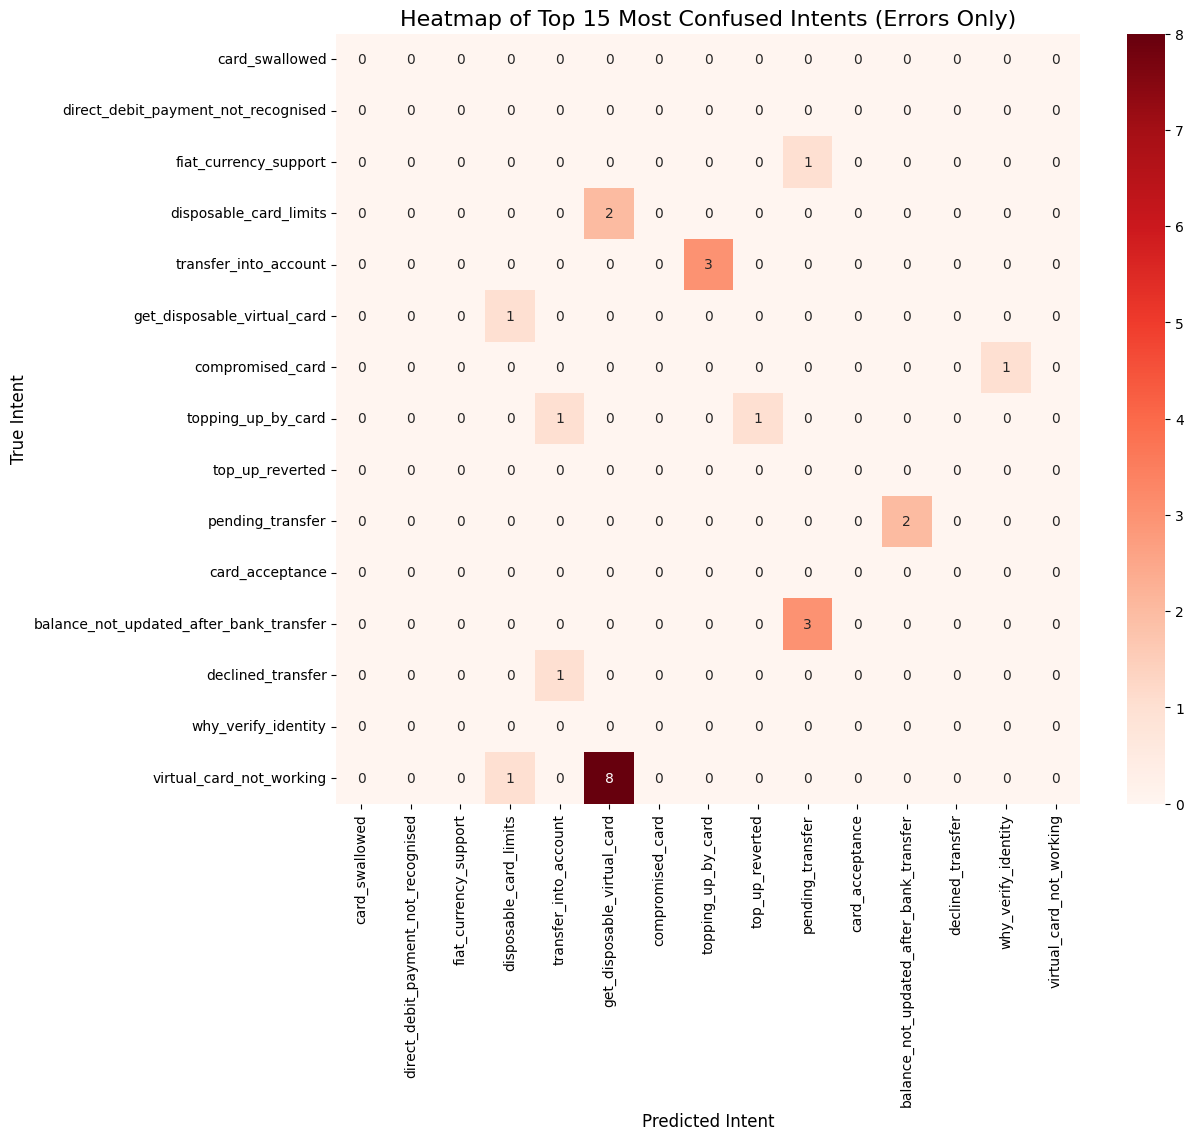


Analysis: The dark squares show the model's biggest weaknesses.
For example, a dark square at (row 'X', col 'Y') means the model
frequently mistakes intent 'X' for intent 'Y'.


In [13]:
# %%
"""
### Cell 10: **NEW** Analysis: Visualize Model Confusion
This cell provides a deeper analysis of the model's errors.
We plot a heatmap of the confusion matrix, but only for the
errors (diagonal is set to 0) to make them easy to see.
"""
print("\n\n--- Cell 10: Visualizing Model Confusion (Error Heatmap) ---")

# Import necessary libraries for plotting
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 2. Create the "Error Matrix" by setting the diagonal to 0
# This hides the thousands of correct predictions to let us see the errors.
error_cm = cm.copy()
np.fill_diagonal(error_cm, 0)

# 3. Find the sum of errors (how many mistakes for each class)
total_errors = np.sum(error_cm, axis=1)
# Find the indices of the 15 most confused classes
top_error_indices = np.argsort(total_errors)[-15:]

# 4. Filter the matrix and labels to *only* show these top 15
top_error_cm = error_cm[top_error_indices, :][:, top_error_indices]
top_error_labels = [label_names[i] for i in top_error_indices]

print(f"Plotting heatmap for the Top 15 most confused intents...")

# 5. Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    top_error_cm,
    annot=True,  # Show the number of errors
    fmt='d',     # Format as integers
    cmap="Reds",
    xticklabels=top_error_labels,
    yticklabels=top_error_labels
)
plt.title('Heatmap of Top 15 Most Confused Intents (Errors Only)', fontsize=16)
plt.ylabel('True Intent', fontsize=12)
plt.xlabel('Predicted Intent', fontsize=12)
plt.show()

print("\nAnalysis: The dark squares show the model's biggest weaknesses.")
print("For example, a dark square at (row 'X', col 'Y') means the model")
print("frequently mistakes intent 'X' for intent 'Y'.")